<a href="https://colab.research.google.com/github/riyaashukla30/AI-ML-Internship-Project/blob/main/CIFAR_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

print("Training Images Shape:", train_images.shape)
print("Training Labels Shape:", train_labels.shape)
print("Testing Images Shape:", test_images.shape)
print("Testing Labels Shape:", test_labels.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


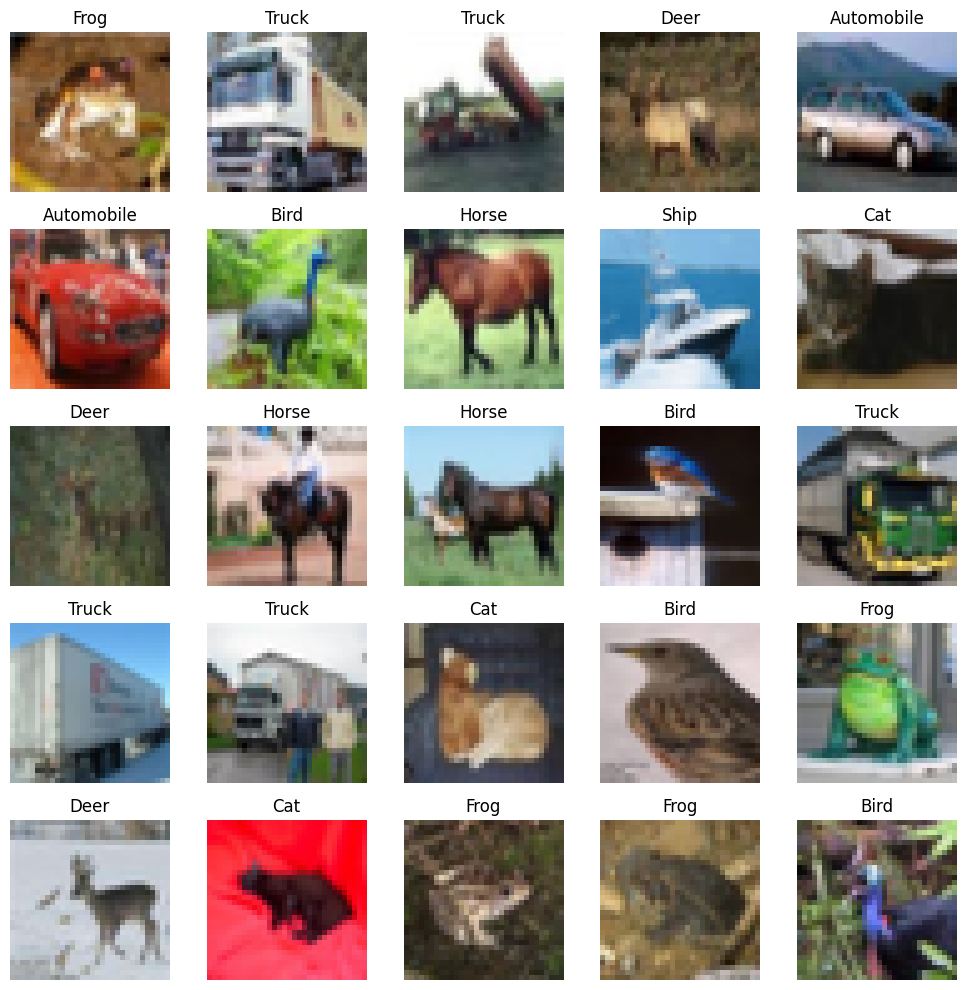

In [3]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

In [5]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

In [7]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 90ms/step - accuracy: 0.4078 - loss: 1.6078 - val_accuracy: 0.4911 - val_loss: 1.4160
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 83ms/step - accuracy: 0.5566 - loss: 1.2391 - val_accuracy: 0.5796 - val_loss: 1.1726
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 83ms/step - accuracy: 0.6204 - loss: 1.0762 - val_accuracy: 0.6168 - val_loss: 1.0988
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 84ms/step - accuracy: 0.6534 - loss: 0.9825 - val_accuracy: 0.6567 - val_loss: 0.9770
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.6806 - loss: 0.9045 - val_accuracy: 0.6757 - val_loss: 0.9187
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.7037 - loss: 0.8445 - val_accuracy: 0.6702 - val_loss: 0.9415
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 89ms/step - accuracy: 0.7225 - loss: 0.7927 - val_accuracy: 0.6877 - val_loss: 0.9112
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.7350 - loss: 0.7571 - 

In [10]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7220 - loss: 0.8272
Test Loss: 0.827189564704895
Test Accuracy: 0.722000002861023


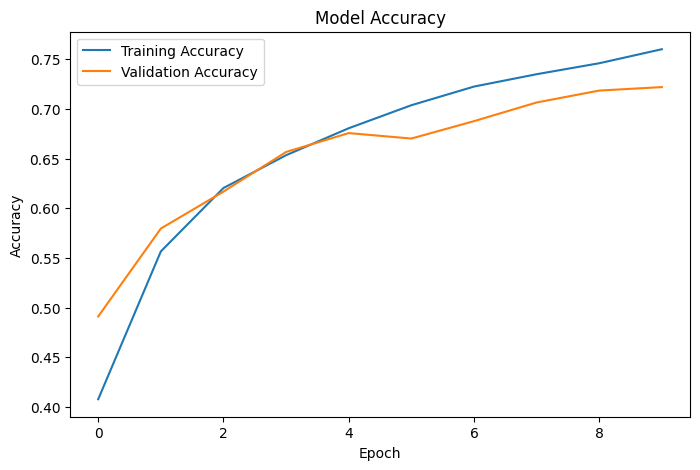

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [12]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


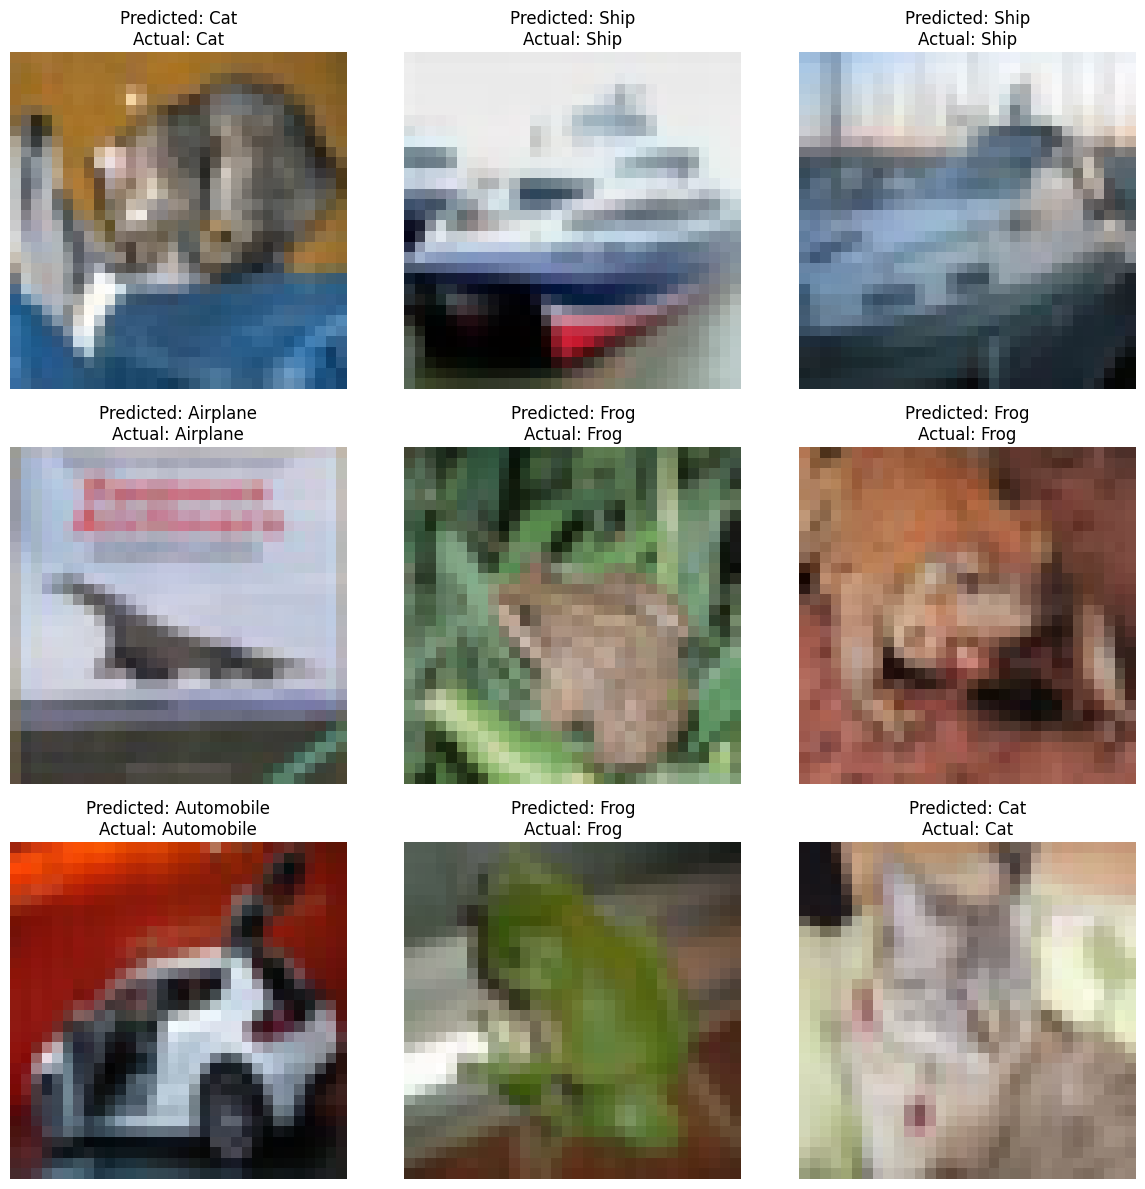

In [13]:
plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(test_images[i])

    predicted_label = np.argmax(predictions[i])

    actual_label = test_labels[i][0]

    plt.title(f"Predicted: {class_names[predicted_label]}\nActual: {class_names[actual_label]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

Predicted Class : Frog
Actual Class    : Ship


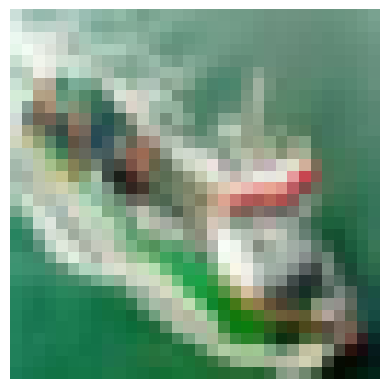

In [14]:
index = 15

plt.imshow(test_images[index])
plt.axis('off')

prediction = np.argmax(predictions[index])

print("Predicted Class :", class_names[prediction])
print("Actual Class    :", class_names[test_labels[index][0]])

In [15]:
model.save("cifar10_image_classifier.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [17]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=2)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

313/313 - 3s - 11ms/step - accuracy: 0.7220 - loss: 0.8272
Test Loss: 0.8272
Test Accuracy: 72.20%


In [18]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


Predicted: Horse
Actual   : Horse


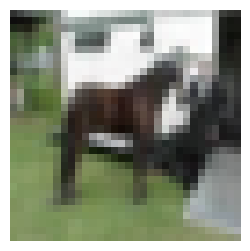

In [19]:
index = 20

plt.figure(figsize=(3,3))
plt.imshow(test_images[index])
plt.axis('off')

predicted_class = np.argmax(predictions[index])
actual_class = test_labels[index][0]

print("Predicted:", class_names[predicted_class])
print("Actual   :", class_names[actual_class])

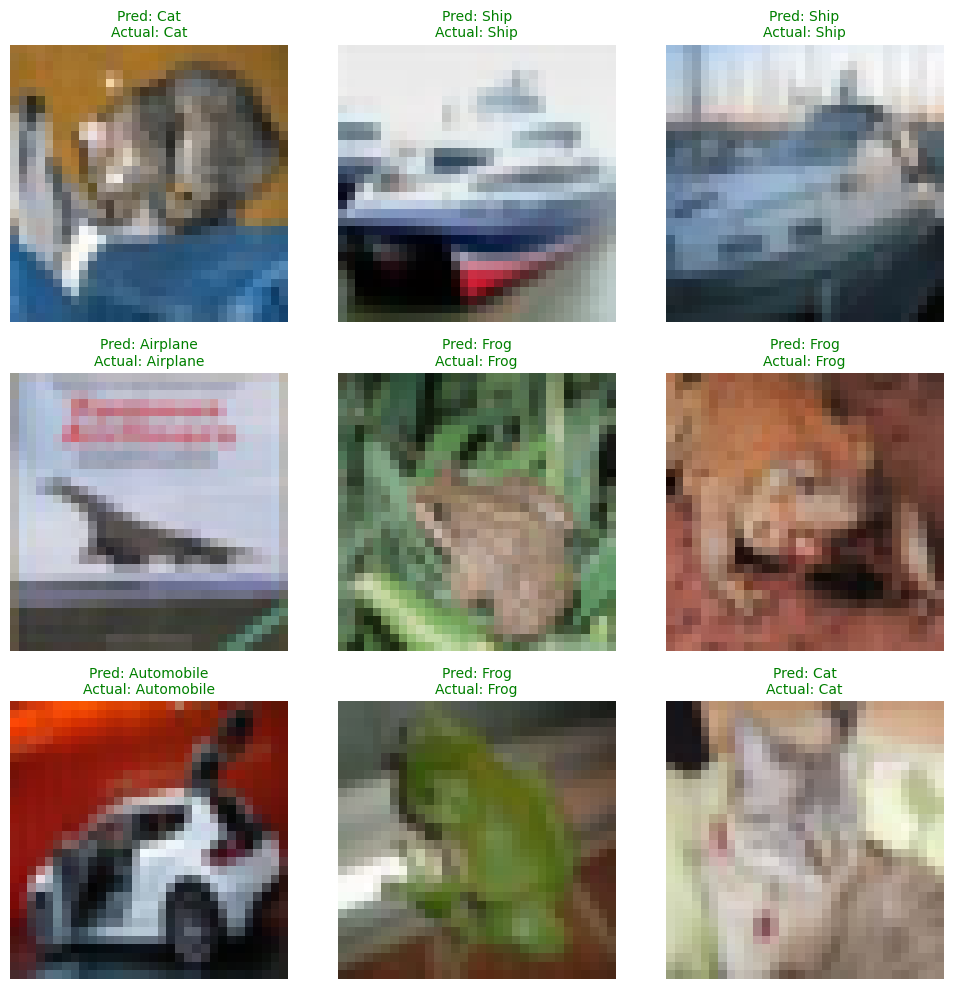

In [20]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(test_images[i])
    plt.axis('off')

    predicted = np.argmax(predictions[i])
    actual = test_labels[i][0]

    color = "green" if predicted == actual else "red"

    plt.title(
        f"Pred: {class_names[predicted]}\nActual: {class_names[actual]}",
        color=color,
        fontsize=10
    )

plt.tight_layout()
plt.show()